
TFG

Este es el codigo del tfg de Borja Jimeno

In [1]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm

import re

sys.path.append('../../')

sys.path.append('../QF_Tamara')
sys.path.append('../QF_DAMA')



from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

In [2]:
import numpy as np


def carga_datos_hist(titulo,archivo):
    file = uproot.open(archivo)
    file.keys()

    graph = file[titulo]
    aux=graph.member("fX")

    longitud=len(aux)
    datos=np.zeros((2,longitud))

    
    
    datos[0]=graph.member("fX")
    datos[1]=graph.member("fY")
    
    return datos


Datos_DM_16=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SDproton","../QF_Tamara/SD_1.root")
Datos_DM_16_ANOD=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_ANOD_DM_SG_SDproton","../QF_Tamara/SD_1.root")

DM_16=Datos_DM_16[1]
DM_16_ANOD=Datos_DM_16_ANOD[1]

DM_16_m=Datos_DM_16[0]
DM_16_ANOD_m=Datos_DM_16_ANOD[0]


Datos_DM_26=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_DM_SG_SDproton","../QF_Tamara/SD_1.root")
Datos_DM_26_ANOD=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_ANOD_DM_SG_SDproton","../QF_Tamara/SD_1.root")

DM_26=Datos_DM_26[1]
DM_26_ANOD=Datos_DM_26_ANOD[1]

DM_26_m=Datos_DM_26[0]
DM_26_ANOD_m=Datos_DM_26_ANOD[0]

masas_ref=Datos_DM_26[0]

DAMA_1=carga_datos_hist("gDAMANa_SDp3s","../QF_Tamara/DAMA_SDp.root")

DAMA_1_s=DAMA_1[1]
DAMA_1_m=DAMA_1[0]

DAMA_2=carga_datos_hist("gDAMAI_SDp3s","../QF_Tamara/DAMA_SDp.root")

DAMA_2_s=DAMA_2[1]
DAMA_2_m=DAMA_2[0]



In [3]:
Datos_DM_16_ANOD_D=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFdama_ANOD_DM_SG_SDproton","../QF_DAMA/Qf_DAMA.root")

DM_16_ANOD_D=Datos_DM_16_ANOD_D[1]

DM_16_ANOD_m_D=Datos_DM_16_ANOD_D[0]

Datos_DM_26_ANOD_D=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFdama_ANOD_DM_SG_SDproton","../QF_DAMA/Qf_DAMA.root")


DM_26_ANOD_D=Datos_DM_26_ANOD_D[1]

DM_26_ANOD_m_D=Datos_DM_26_ANOD_D[0]



In [4]:
def elimina_sing(array_d,array_m):
    aa=0
    while(aa==0):
        if (array_d[0]<0 or array_d[0]>1):
            array_d=np.delete(array_d,0)
            array_m=np.delete(array_m,0)
        else:
            aa=1
    return array_d,array_m

DM_16, DM_16_m = elimina_sing(DM_16,DM_16_m)

DM_16_ANOD, DM_16_ANOD_m = elimina_sing(DM_16_ANOD,DM_16_ANOD_m)

DM_26, DM_26_m = elimina_sing(DM_26,DM_26_m)

DM_26_ANOD, DM_26_ANOD_m = elimina_sing(DM_26_ANOD,DM_26_ANOD_m)




DM_16_ANOD_D, DM_16_ANOD_m_D = elimina_sing(DM_16_ANOD_D,DM_16_ANOD_m_D)


DM_26_ANOD_D, DM_26_ANOD_m_D = elimina_sing(DM_26_ANOD_D,DM_26_ANOD_m_D)





In [5]:


COSINE=np.loadtxt("../QF_Tamara/COSINE-100.txt")

COSINE_x=[]
COSINE_y=[]

for i in range(len(COSINE)):
    COSINE_x.append(COSINE[i][0])
    COSINE_y.append(COSINE[i][1])



In [6]:
def imprime_plot(e_i,e_s,tipo,print_plot=0):
    
    nombre=""

    prin1="gA112_6y_90_"
    prin2="_QFtamara_"

    modos=("DM_SG_SI","PY_SI","RA_SI","WI_SI","DMA_SI")

    nombre=prin1+f'{e_i:.6f}'+"_"+f'{e_s:.6f}'+prin2+modos[tipo]

    file = uproot.open("SI_varios_intervalos.root")
    graph = file[nombre]

    
    x_aux=graph.member("fX")
    y_aux=graph.member("fY")
    
    x=[]
    y=[]

    for i in range(len(x_aux)):
        if y_aux[i]<1e-35:
            if y_aux[i]>1e-55:
                x.append(x_aux[i])
                y.append(y_aux[i])

                

    
    if print_plot==1:
            plt.figure(figsize=(14, 8))
            ax = plt.subplot()

            ax.plot(x,y)


            #ax.legend()
            ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
            ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
            ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

            ax.set_yscale("log")
            ax.set_xscale("log")

            y_sup=1e-35
            y_inf=1e-45

            ax.set_ylim(y_inf,y_sup)
            ax.set_xlim(1,1000)

            exp_min = int(np.floor(np.log10(y_inf)))   
            exp_max = int(np.ceil(np.log10(y_sup)))    
            exps = np.arange(exp_min, exp_max)     


            all_ticks = []
            for e in exps:
                decade = (np.arange(1, 10) * (10.0**e)).tolist()
                all_ticks.extend(decade)
            all_ticks = np.array(all_ticks)

            ax.set_yticks(all_ticks)                    

            ax.grid(which='both', linestyle='-', alpha=0.2)

    return x,y

def encuentra_intervalo(cadena):
    valores = re.findall(r"\d+\.\d+", cadena)
    a=np.zeros(2)
    a[0]=float(valores[0])
    a[1]=float(valores[1])
    return a

def genera_lista_modos(lista_modos):
    lista_ref=(0,1,2,3,4)
    lista_ref=np.array(lista_ref)
    if (type(lista_modos)==int):
        a=np.where(lista_ref == lista_modos,1,0)
        return a
        
    else:
        lista_modos=np.array(lista_modos)
        a=np.zeros(len(lista_ref),dtype=int)
        for i in range (len(lista_modos)):
            a+=np.where(lista_ref == lista_modos[i],1,0)
        return a

def lista_intervalo(lista_energias,anod_bool):
    
    list_names=[]
    list_energies=[]

    prin1="gA112_6y_90_"
    prin2="_QFtamara_"
    
    if anod_bool==0:
        modos="DM_SG_SDproton"

    if anod_bool==1:
        modos="ANOD_DM_SG_SDproton"
    

    for i in range (len(lista_energias)):
            intervalo_minimo=np.zeros(2)
            list_names.append(prin1+f'{lista_energias[i][0]:.6f}'+"_"+f'{lista_energias[i][1]:.6f}'+prin2+modos)
            intervalo_minimo[0]=lista_energias[i][0]
            intervalo_minimo[1]=lista_energias[i][1]
            list_energies.append(intervalo_minimo)


    return list_names, list_energies

def carga_datos_hist(lista_energias,anod_bool,filename):

    lista_nombres, list_energies=lista_intervalo(lista_energias,anod_bool)
    
    file = uproot.open(filename)
    
    datos=[]
    intervalos=[]
    resultado=[]

    for i in range(len(lista_nombres)):

        valores=list_energies[i]
        nombre=lista_nombres[i]

        graph = file[nombre]
        
        masas=graph.member("fX")
        valores=graph.member("fY")

        valores, masas = elimina_sing(valores,masas)

        aux=np.ones((2,len(valores)))

        aux[0]=masas
        aux[1]=valores

        datos.append(aux)
        intervalos.append(valores)
    
    resultado.append(datos)
    resultado.append(intervalos)
    return resultado, lista_nombres

def minimiza_lista_datos(lista_datos,lista_energias,array_masas):
    
    
    masas=[]
    sigmas=[]
    int_min=[]

   

    for m in masas_ref:
        sigma_aux=1
        masa_ref=0
        intervalo_minimo=np.zeros(2)
        
        for j in range (len(lista_datos[1])):
            a=0

            a=np.where(lista_datos[0][j][0]==m,lista_datos[0][j][1],0)
            a_norm=np.linalg.norm(a)

            if(a_norm!=0):
                masa_ref=1
                if(a_norm<sigma_aux):
                    sigma_aux=a_norm
                    intervalo_minimo[0]=lista_energias[j][0]
                    intervalo_minimo[1]=lista_energias[j][1]
    
        if masa_ref==1:
            sigmas.append(sigma_aux)
            masas.append(m)
            int_min.append(intervalo_minimo)

    return masas,sigmas,int_min

def imprime_intervalo_optimo(masas,intervalo_minimo):
    for i in range (len(masas)):
        print(f'Mass: {masas[i]:.1f} GeV - Minimum Exlussion Interval:  ({intervalo_minimo[i][0]} - {intervalo_minimo[i][1]}) keV ')

In [7]:
lista_energias_ANOD = np.loadtxt('../QF_Tamara/list_energies_SDp_ANOD.txt')

lista_datos_ANOD, lista_nombres_ANOD=carga_datos_hist(lista_energias_ANOD,1,'../QF_Tamara/SD_1.root')

masas_opt_ANOD,sigmas_opt_ANOD,intervalo_minimo_ANOD=minimiza_lista_datos(lista_datos_ANOD,lista_energias_ANOD,masas_ref)

imprime_intervalo_optimo(masas_opt_ANOD,intervalo_minimo_ANOD)

Mass: 2.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 2.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 2.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 4.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.

In [8]:
def imprime_plot(e_i,e_s,tipo,print_plot=0):
    
    nombre=""

    prin1="gA112_6y_90_"
    prin2="_QFdama_"

    modos=("DM_SG_SI","PY_SI","RA_SI","WI_SI","DMA_SI")

    nombre=prin1+f'{e_i:.6f}'+"_"+f'{e_s:.6f}'+prin2+modos[tipo]

    file = uproot.open("SI_varios_intervalos.root")
    graph = file[nombre]

    
    x_aux=graph.member("fX")
    y_aux=graph.member("fY")
    
    x=[]
    y=[]

    for i in range(len(x_aux)):
        if y_aux[i]<1e-35:
            if y_aux[i]>1e-55:
                x.append(x_aux[i])
                y.append(y_aux[i])

                

    
    if print_plot==1:
            plt.figure(figsize=(14, 8))
            ax = plt.subplot()

            ax.plot(x,y)


            #ax.legend()
            ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
            ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
            ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

            ax.set_yscale("log")
            ax.set_xscale("log")

            y_sup=1e-35
            y_inf=1e-45

            ax.set_ylim(y_inf,y_sup)
            ax.set_xlim(1,1000)

            exp_min = int(np.floor(np.log10(y_inf)))   
            exp_max = int(np.ceil(np.log10(y_sup)))    
            exps = np.arange(exp_min, exp_max)     


            all_ticks = []
            for e in exps:
                decade = (np.arange(1, 10) * (10.0**e)).tolist()
                all_ticks.extend(decade)
            all_ticks = np.array(all_ticks)

            ax.set_yticks(all_ticks)                    

            ax.grid(which='both', linestyle='-', alpha=0.2)

    return x,y

def encuentra_intervalo(cadena):
    valores = re.findall(r"\d+\.\d+", cadena)
    a=np.zeros(2)
    a[0]=float(valores[0])
    a[1]=float(valores[1])
    return a

def genera_lista_modos(lista_modos):
    lista_ref=(0,1,2,3,4)
    lista_ref=np.array(lista_ref)
    if (type(lista_modos)==int):
        a=np.where(lista_ref == lista_modos,1,0)
        return a
        
    else:
        lista_modos=np.array(lista_modos)
        a=np.zeros(len(lista_ref),dtype=int)
        for i in range (len(lista_modos)):
            a+=np.where(lista_ref == lista_modos[i],1,0)
        return a

def lista_intervalo(lista_energias,anod_bool):
    
    list_names=[]
    list_energies=[]

    prin1="gA112_6y_90_"
    prin2="_QFdama_"
    
    if anod_bool==0:
        modos="DM_SG_SDproton"

    if anod_bool==1:
        modos="ANOD_DM_SG_SDproton"
    

    for i in range (len(lista_energias)):
            intervalo_minimo=np.zeros(2)
            list_names.append(prin1+f'{lista_energias[i][0]:.6f}'+"_"+f'{lista_energias[i][1]:.6f}'+prin2+modos)
            intervalo_minimo[0]=lista_energias[i][0]
            intervalo_minimo[1]=lista_energias[i][1]
            list_energies.append(intervalo_minimo)


    return list_names, list_energies

def carga_datos_hist(lista_energias,anod_bool,filename):

    lista_nombres, list_energies=lista_intervalo(lista_energias,anod_bool)
    
    file = uproot.open(filename)
    
    datos=[]
    intervalos=[]
    resultado=[]

    for i in range(len(lista_nombres)):

        valores=list_energies[i]
        nombre=lista_nombres[i]

        graph = file[nombre]
        
        masas=graph.member("fX")
        valores=graph.member("fY")

        valores, masas = elimina_sing(valores,masas)

        aux=np.ones((2,len(valores)))

        aux[0]=masas
        aux[1]=valores

        datos.append(aux)
        intervalos.append(valores)
    
    resultado.append(datos)
    resultado.append(intervalos)
    return resultado, lista_nombres

def minimiza_lista_datos(lista_datos,lista_energias,array_masas):
    
    
    masas=[]
    sigmas=[]
    int_min=[]

   

    for m in masas_ref:
        sigma_aux=1
        masa_ref=0
        intervalo_minimo=np.zeros(2)
        
        for j in range (len(lista_datos[1])):
            a=0

            a=np.where(lista_datos[0][j][0]==m,lista_datos[0][j][1],0)
            a_norm=np.linalg.norm(a)

            if(a_norm!=0):
                masa_ref=1
                if(a_norm<sigma_aux):
                    sigma_aux=a_norm
                    intervalo_minimo[0]=lista_energias[j][0]
                    intervalo_minimo[1]=lista_energias[j][1]
    
        if masa_ref==1:
            sigmas.append(sigma_aux)
            masas.append(m)
            int_min.append(intervalo_minimo)

    return masas,sigmas,int_min

def imprime_intervalo_optimo(masas,intervalo_minimo):
    for i in range (len(masas)):
        print(f'Mass: {masas[i]:.1f} GeV - Minimum Exlussion Interval:  ({intervalo_minimo[i][0]} - {intervalo_minimo[i][1]}) keV ')

In [9]:
masas_ref=Datos_DM_26_ANOD_D[0]

lista_energias_ANOD_D = np.loadtxt('../QF_DAMA/list_energies_SDp_ANOD.txt')

lista_datos_ANOD_D, lista_nombres_ANOD_D=carga_datos_hist(lista_energias_ANOD_D,1,'../QF_DAMA/Qf_DAMA.root')

masas_opt_ANOD_D,sigmas_opt_ANOD_D,intervalo_minimo_ANOD_D=minimiza_lista_datos(lista_datos_ANOD_D,lista_energias_ANOD_D,masas_ref)

imprime_intervalo_optimo(masas_opt_ANOD_D,intervalo_minimo_ANOD_D)

Mass: 2.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 2.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 2.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 2.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 3.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 3.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 3.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 3.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.

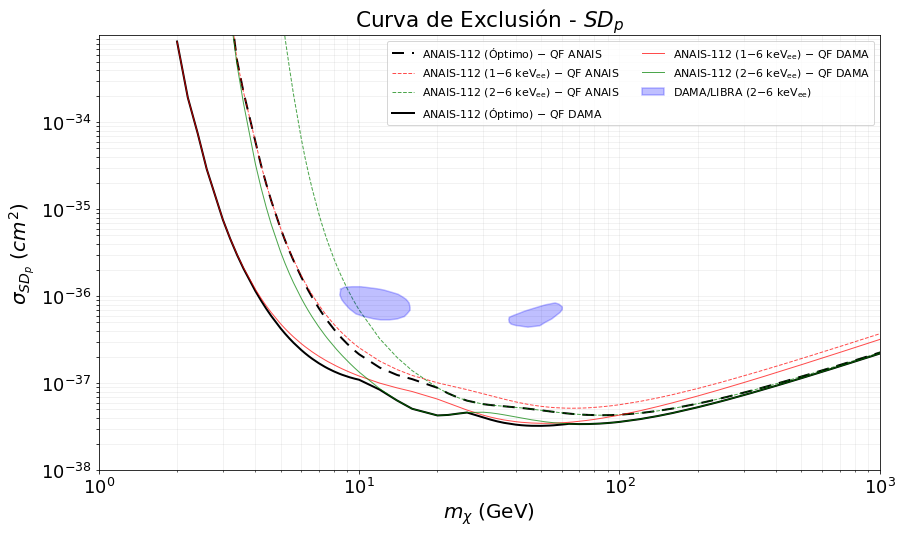

In [10]:
import itertools
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


# --- QF Tamara (dependiente de energía): líneas discontinuas ---
ax.plot(masas_opt_ANOD, sigmas_opt_ANOD, linestyle=(0, (6, 4, 6, 4)),
        linewidth=2, c="black", alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")
ax.plot(DM_16_ANOD_m, DM_16_ANOD, linestyle='--', linewidth=1, c="red",
        alpha=0.7, label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")
ax.plot(DM_26_ANOD_m, DM_26_ANOD, linestyle='--', linewidth=1, c="green",
        alpha=0.7, label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")

# --- QF DAMA (constante): líneas continuas ---
ax.plot(masas_opt_ANOD_D, sigmas_opt_ANOD_D, linestyle='-', linewidth=2,
        c="black", alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")
ax.plot(DM_16_ANOD_m_D, DM_16_ANOD_D, linestyle='-', linewidth=1, c="red",
        alpha=0.7, label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")
ax.plot(DM_26_ANOD_m_D, DM_26_ANOD_D, linestyle='-', linewidth=1, c="green",
        alpha=0.7, label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")


# --- Regiones DAMA/LIBRA ---
ax.fill(DAMA_1_m, DAMA_1_s, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax.fill(DAMA_2_m, DAMA_2_s, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5)



#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.legend(fontsize=11, ncol=2, loc='upper right')

ax.set_title(r'Curva de Exclusión - $SD_p$')
ax.set_ylabel(r'$\sigma_{SD_p}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-33
y_inf=1e-38


ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)


plt.savefig("Final_SDp.pdf", dpi=150, facecolor='white',bbox_inches='tight')


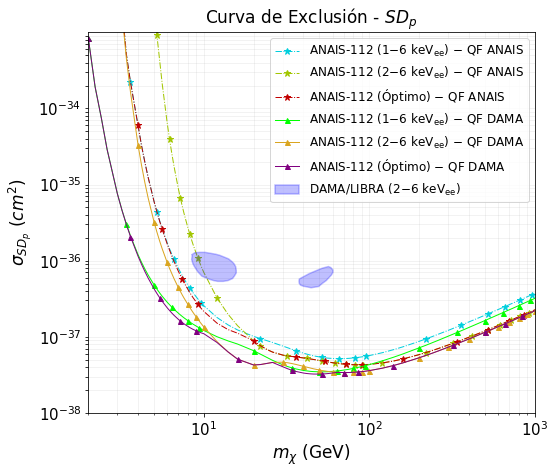

In [14]:
import itertools
plt.figure(figsize=(8, 7), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


ax.plot(DM_16_ANOD_m, DM_16_ANOD, linestyle='-.', linewidth=1, c="#00CFDD",marker="*", markersize=7,markevery=6, alpha=1,
         label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")
ax.plot(DM_26_ANOD_m, DM_26_ANOD, linestyle='-.', linewidth=1, c="#A2C600",marker="*", markersize=7,markevery=4, alpha=1,
         label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")

ax.plot(masas_opt_ANOD, sigmas_opt_ANOD, linestyle='-.',
        linewidth=1, c="#C20000",marker="*", markersize=7,markevery=7, alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")




ax.plot(DM_16_ANOD_m_D, DM_16_ANOD_D, linestyle='-', linewidth=1,c="lime",marker="^", markersize=5,markevery=6, alpha=1,
         label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

ax.plot(DM_26_ANOD_m_D, DM_26_ANOD_D, linestyle='-', linewidth=1, c="#DAA520",marker="^", markersize=5,markevery=4, alpha=1,
        label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

ax.plot(masas_opt_ANOD_D, sigmas_opt_ANOD_D, linestyle='-', linewidth=1,
        c="purple",marker="^", markersize=5,markevery=7, alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")




# --- Regiones DAMA/LIBRA ---
ax.fill(DAMA_1_m, DAMA_1_s, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax.fill(DAMA_2_m, DAMA_2_s, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5)



#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")



ax.set_title(r'Curva de Exclusión - $SD_p$',fontsize=17)
ax.set_ylabel(r'$\sigma_{SD_p}$ $(cm^2)$',fontsize=17)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=17)

ax.set_yscale("log")
ax.set_xscale("log")

ax.tick_params(axis='both', which='major', labelsize=15)

ax.legend(fontsize=12, loc='upper right')

y_sup=1e-33
y_inf=1e-38


ax.set_ylim(y_inf,y_sup)
ax.set_xlim(2,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)


plt.savefig("Final_SDp_half.pdf", dpi=150, facecolor='white',bbox_inches='tight')


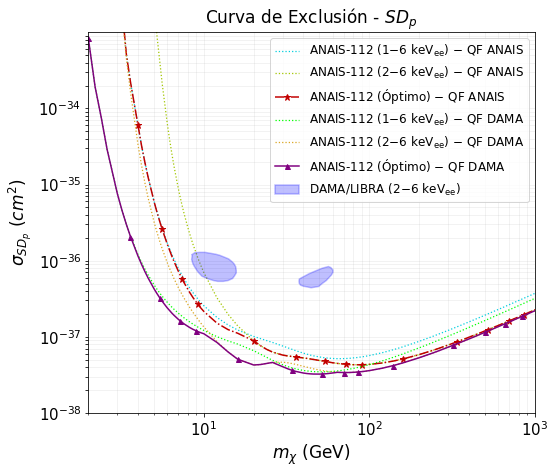

In [15]:
import itertools
plt.figure(figsize=(8, 7), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


ax.plot(DM_16_ANOD_m, DM_16_ANOD, linestyle=':', linewidth=1.25, c="#00CFDD", alpha=1,
         label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")
ax.plot(DM_26_ANOD_m, DM_26_ANOD, linestyle=':', linewidth=1.25, c="#A2C600", alpha=1,
         label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")

ax.plot(masas_opt_ANOD, sigmas_opt_ANOD, linestyle='-.',
        linewidth=1.5, c="#C20000",marker="*", markersize=7,markevery=7, alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")




ax.plot(DM_16_ANOD_m_D, DM_16_ANOD_D, linestyle=':', linewidth=1.25,c="lime", alpha=1,
         label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

ax.plot(DM_26_ANOD_m_D, DM_26_ANOD_D, linestyle=':', linewidth=1.25, c="#DAA520", alpha=1,
        label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

ax.plot(masas_opt_ANOD_D, sigmas_opt_ANOD_D, linestyle='-',  linewidth=1.5,
        c="purple",marker="^", markersize=5,markevery=7, alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")




# --- Regiones DAMA/LIBRA ---
ax.fill(DAMA_1_m, DAMA_1_s, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax.fill(DAMA_2_m, DAMA_2_s, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5)



#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")



ax.set_title(r'Curva de Exclusión - $SD_p$',fontsize=17)
ax.set_ylabel(r'$\sigma_{SD_p}$ $(cm^2)$',fontsize=17)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=17)

ax.set_yscale("log")
ax.set_xscale("log")

ax.tick_params(axis='both', which='major', labelsize=15)

ax.legend(fontsize=12, loc='upper right')

y_sup=1e-33
y_inf=1e-38


ax.set_ylim(y_inf,y_sup)
ax.set_xlim(2,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)


plt.savefig("Final_SDp_half_2.pdf", dpi=150, facecolor='white',bbox_inches='tight')
